# Lab 3: Problem 1 — Coin Change (Dynamic Programming)

---

## 1. Dynamic Programming Formulation
- **State Definition**: Let $DP[a]$ represent the **minimum number of coins** required to form a target amount $a$.
- **Base Cases**:
  - $DP[0] = 0$ (Zero coins are required to form an amount of $0$).
  - $DP[a] = \infty$ for all $a > 0$ (Initialized to infinity).
- **Recurrence Relation (State Transition)**:
  $$DP[a] = 1 + \min_{\substack{c \in \text{coins} \\ c \le a}} DP[a - c]$$
- **No Solution Handling**: If $DP[\text{amount}] = \infty$, the target amount cannot be formed using the given denominations (report no solution / return `-1`).


In [1]:
def coin_change_dp(coins, amount):
    """Bottom-up Dynamic Programming with coin combination reconstruction."""
    dp = [0] + [float('inf')] * amount
    parent = [-1] * (amount + 1)
    
    for a in range(1, amount + 1):
        for c in coins:
            if c <= a and dp[a - c] + 1 < dp[a]:
                dp[a] = dp[a - c] + 1
                parent[a] = c
                
    if dp[amount] == float('inf'):
        return -1, []
    
    # Reconstruct optimal coin combination
    combination, curr = [], amount
    while curr > 0:
        c = parent[curr]
        combination.append(c)
        curr -= c
        
    return dp[amount], combination

# Example from PDF
coins = [1, 3, 4]
amount = 6
min_coins, combo = coin_change_dp(coins, amount)

print(f"Denominations : {coins}")
print(f"Target Amount : {amount}")
print(f"Minimum Coins : {min_coins}")
print(f"Combination   : {' + '.join(map(str, combo))} = {amount}")

# Boundary Cases
print("\n--- Boundary Cases ---")
print(f"Target 0: min_coins = {coin_change_dp(coins, 0)[0]}, combination = {coin_change_dp(coins, 0)[1]}")
print(f"Unreachable Target (coins=[2, 4], amount=7): {coin_change_dp([2, 4], 7)}")


Denominations : [1, 3, 4]
Target Amount : 6
Minimum Coins : 2
Combination   : 3 + 3 = 6

--- Boundary Cases ---
Target 0: min_coins = 0, combination = []
Unreachable Target (coins=[2, 4], amount=7): (-1, [])


---

## 2. Comparison: DP vs. Recursive Approach

| Metric | Bottom-Up Dynamic Programming | Naive Recursive Approach |
| :--- | :--- | :--- |
| **Time Complexity** | $\mathcal{O}(n \cdot A)$ | $\mathcal{O}(n^A)$ (Exponential) |
| **Auxiliary Space** | $\mathcal{O}(A)$ (DP & parent arrays) | $\mathcal{O}(A)$ (Recursion call stack) |
| **Subproblem Overlap** | Computes each subproblem exactly once | Recomputes overlapping subproblems exponentially |

*(where $n = |\text{coins}|$ is the number of denominations and $A = \text{amount}$ is the target amount)*


In [2]:
def coin_change_rec(coins, amount):
    """Naive recursive implementation without memoization."""
    if amount == 0:
        return 0
    min_coins = float('inf')
    for c in coins:
        if c <= amount:
            res = coin_change_rec(coins, amount - c)
            if res != float('inf'):
                min_coins = min(min_coins, 1 + res)
    return min_coins


---

## 3. Empirical Execution Time Experimentation & Graphs
We measure and observe the execution time behavior of:
1. **DP vs. Naive Recursion** across target amounts ($A \in [1, 25]$).
2. **Bottom-Up DP Scalability** across larger target amounts ($A \in [100, 2000]$).


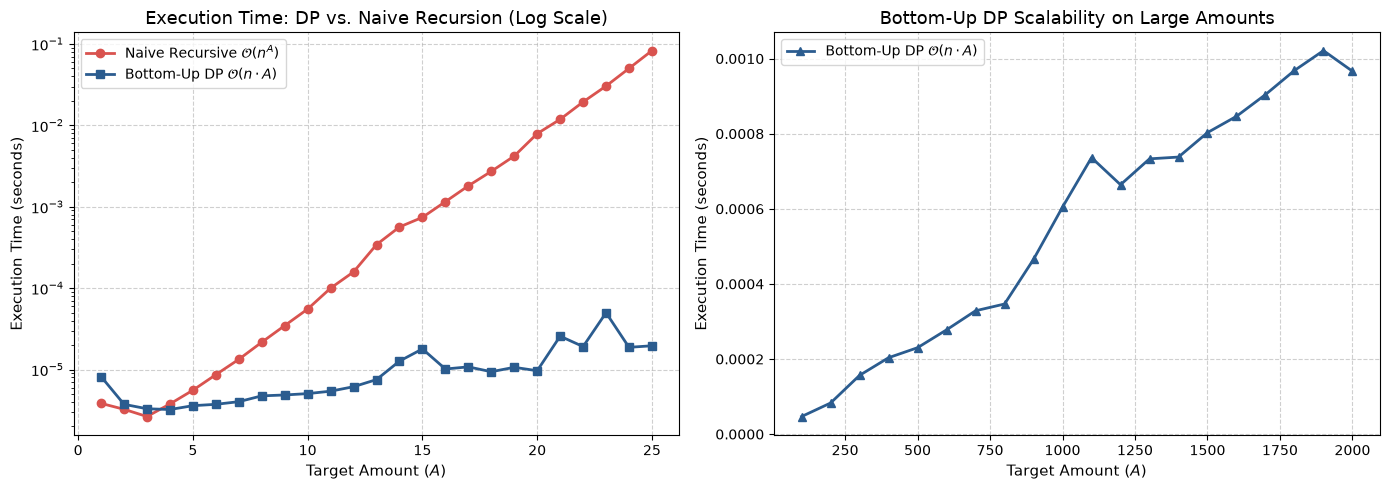

In [3]:
import time
import matplotlib.pyplot as plt

# 1. Benchmark DP vs. Recursion (Moderate amounts)
amounts_small = list(range(1, 26))
coins_test = [1, 3, 4]

dp_times, rec_times = [], []
for a in amounts_small:
    # Measure DP
    t0 = time.perf_counter()
    coin_change_dp(coins_test, a)
    dp_times.append(time.perf_counter() - t0)
    
    # Measure Naive Recursion
    t0 = time.perf_counter()
    coin_change_rec(coins_test, a)
    rec_times.append(time.perf_counter() - t0)

# 2. Benchmark DP Scalability on Large Amounts
amounts_large = list(range(100, 2001, 100))
dp_large_times = []
for a in amounts_large:
    t0 = time.perf_counter()
    coin_change_dp(coins_test, a)
    dp_large_times.append(time.perf_counter() - t0)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: DP vs Recursion
axes[0].plot(amounts_small, rec_times, 'o-', color='#d9534f', label=r'Naive Recursive $\mathcal{O}(n^A)$', linewidth=2)
axes[0].plot(amounts_small, dp_times, 's-', color='#2b5c8f', label=r'Bottom-Up DP $\mathcal{O}(n \cdot A)$', linewidth=2)
axes[0].set_title('Execution Time: DP vs. Naive Recursion (Log Scale)', fontsize=13)
axes[0].set_xlabel('Target Amount ($A$)', fontsize=11)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graph 2: DP Scalability
axes[1].plot(amounts_large, dp_large_times, '^-', color='#2b5c8f', label=r'Bottom-Up DP $\mathcal{O}(n \cdot A)$', linewidth=2)
axes[1].set_title('Bottom-Up DP Scalability on Large Amounts', fontsize=13)
axes[1].set_xlabel('Target Amount ($A$)', fontsize=11)
axes[1].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


---

## 4. Analysis: Greedy Strategy vs. Dynamic Programming

### Does Greedy Always Produce the Minimum Number of Coins?
**No.** The greedy strategy selects the largest possible coin denomination $c \le \text{remaining amount}$ at each step. While greedy works for canonical coin systems (e.g., standard currency), it often fails for arbitrary coin denominations.

### Counterexample (from PDF):
- **Denominations**: $\{1, 3, 4\}$, **Target Amount**: $6$
- **Greedy Strategy**:
  1. Picks $4$ (Remaining amount: $2$)
  2. Picks $1$ (Remaining amount: $1$)
  3. Picks $1$ (Remaining amount: $0$)
  - **Greedy Total**: **3 coins** ($4 + 1 + 1$)
- **Dynamic Programming (Optimal)**:
  - Selects $3 + 3 = 6$
  - **DP Total**: **2 coins** ($3 + 3$)

### Why Dynamic Programming Succeeds where Greedy Fails:
- **Greedy** makes a short-sighted local choice (largest denomination), which can force suboptimal smaller coins later.
- **Dynamic Programming** explores all feasible coin choices at every subproblem amount $a - c$, memoizing the minimum. By leveraging **optimal substructure** and **overlapping subproblems**, DP guarantees finding the global minimum.


In [4]:
def coin_change_greedy(coins, amount):
    """Greedy approach picking the largest denomination available."""
    sorted_coins = sorted(coins, reverse=True)
    combo, curr = [], amount
    for c in sorted_coins:
        while curr >= c:
            combo.append(c)
            curr -= c
    return len(combo) if curr == 0 else -1, combo

coins = [1, 3, 4]
amount = 6

g_count, g_combo = coin_change_greedy(coins, amount)
dp_count, dp_combo = coin_change_dp(coins, amount)

print("=== Counterexample Comparison (Denominations: [1, 3, 4], Target: 6) ===")
print(f"Greedy Result : {g_count} coins -> {g_combo} (Suboptimal)")
print(f"DP Result     : {dp_count} coins -> {dp_combo} (Optimal)")


=== Counterexample Comparison (Denominations: [1, 3, 4], Target: 6) ===
Greedy Result : 3 coins -> [4, 1, 1] (Suboptimal)
DP Result     : 2 coins -> [3, 3] (Optimal)
